# Week 6 (Tree-based Models)

## 2.1. Decision Tree

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import graphviz
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn import datasets
from sklearn.model_selection import train_test_split

In [11]:
# 데이터 로드 및 전처리
iris = datasets.load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

# 훈련/테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Q1.1 max_depth 파라미터를 변경하면 트리의 구조와 성능이 어떻게 변할까요?

In [21]:
# 결정 트리 모델 생성 및 학습
tree_model = DecisionTreeClassifier(criterion="gini", max_depth=3, min_samples_leaf=2, random_state=42)
tree_model.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=3, min_samples_leaf=2, random_state=42)

`max_depth` 는 트리가 뻗어 내려갈 수 있는 최대 깊이를 제한하는 파라미터입니다.

너무 작으면 트리가 단순해져 underfitting이 될 수 있고,
너무 커지면 overfitting이 될 수 있습니다.

따라서 일반적으로 깊이가 증가할수록 train의 정확도는 증가하지만 test의 정확도는 계속 증가하지 않고 특정 지점까지 증가하다가 감소할 수 있습니다.

In [20]:
# max_depth에 따른 성능 변화 확인
for depth in [1, 2, 3, 4, None]:
    model = DecisionTreeClassifier(
        criterion='gini',
        max_depth=depth,
        min_samples_leaf=2,
        random_state=42
    )
    model.fit(X_train, y_train)
    print(
        f'max_depth={str(depth):>4} | '
        f'train accuracy={model.score(X_train, y_train):.3f} | '
        f'test accuracy={model.score(X_test, y_test):.3f}'
    )


max_depth=   1 | train accuracy=0.675 | test accuracy=0.633
max_depth=   2 | train accuracy=0.950 | test accuracy=0.967
max_depth=   3 | train accuracy=0.950 | test accuracy=1.000
max_depth=   4 | train accuracy=0.967 | test accuracy=1.000
max_depth=None | train accuracy=0.975 | test accuracy=1.000


### Q1.2 'gini'와 'entropy' 기준의 차이는 무엇이며, 결과에 어떤 영향을 미칠까요?

`gini impurity` 는 노드에서 무작위로 뽑은 샘플이 잘못 분류될 확률을 기반으로 하여, 로그 연산이 없어 계산이 빠릅니다.

`entropy` 는 불순도를 정보량 단위로 측정하며, 로그 계산이 필요해 gini에 비해 계산 비용이 큽니다.

두 기준으로 만든 트리의 성능 차이는 대부분 크지 않다고 합니다. 다만 차이가 있다면, `entropy`는 클래스 분포가 더 균형 잡힌 분할을 선호하는 경향이 있고, `gini`는 계산 효율이 좋아 sklearn의 기본값으로 사용됩니다.

### Q1.3 각 노드의 분할 기준 어떻게 되는지 설명해보세요.

각 노드에서는 가능한 feature과 threshold 조합을 여러 개 비교한 뒤, 자식 노드들의 가중 불순도가 가장 작아지도록 하는 분할을 선택합니다. 현재 모델은 `criterion="gini"`이므로 **Gini impurity를 가장 많이 감소시키는 분할**을 고릅니다.

현재 설정(`random_state=42`, `max_depth=3`, `min_samples_leaf=2`)에서는 대표적으로 다음과 같이 분할됩니다.

1. 루트 노드: `petal length (cm) <= 2.45` 여부로 분할
   - 2.45 이하이면 대부분 **setosa**
   - 2.45 초과이면 versicolor/virginica를 추가로 구분
2. 다음 주요 분할: `petal length (cm) <= 4.75`
3. 이후 `petal width (cm) <= 1.55`, `petal width (cm) <= 1.75` 등의 기준을 사용

즉, 학습 데이터에서 여러 후보를 계산한 뒤 **불순도 감소가 가장 큰 기준을 알고리즘이 자동으로 선택**합니다.


In [13]:
# 트리 시각화 (Graphviz)
dot_data = export_graphviz(
    tree_model,
    out_file=None,
    feature_names=X.columns,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    special_characters=True
)

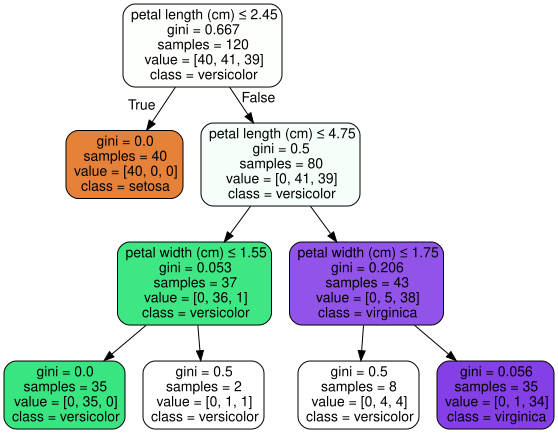

In [14]:
# 그래프 출력
graph = graphviz.Source(dot_data)
graph

## 3. 앙상블 학습: 부스팅(Boosting) 모델

Adaboost, Gradient Boosting Model은 scikit learn에서 지원하지만, LightGBM과 XGBoost의 경우는 외부 패키지를 불러와야 합니다.

Boosting 계열의 모델들은 데이터 개수가 적으면 overfitting이 일어나는 경우가 많으니, 주의해야 합니다.

In [15]:
# 필요한 패키지 로드
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_squared_error

housing = fetch_california_housing()

In [16]:
# 데이터 로드
housing_df = pd.DataFrame(housing.data, columns=housing.feature_names)
housing_df['MedHouseVal'] = housing.target

In [17]:
housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### Q3.1 `housing_df`를 train, test split을 해봅시다.

분할 비율을 자유롭게 설정해봅시다.

In [22]:
# 데이터 분할
X = housing_df.drop(columns=['MedHouseVal'])
y = housing_df['MedHouseVal']

# 전체 데이터의 80%는 train, 20%는 test로 사용
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('X_train shape:', X_train.shape)
print('X_test shape :', X_test.shape)

# 이후 모델들의 MSE를 한눈에 비교하기 위해 결과를 저장할 딕셔너리
model_results = {}


X_train shape: (16512, 8)
X_test shape : (4128, 8)


### Q3.2  데이터를 `RandomForestRegressor`에 적합해 봅시다.
train set 에 대해 `MedHouseVal`을 종속변수, 나머지를 독립변수로 하는 random forest regressor를 적합해 봅시다.

test set으로 prediction을 한 후 MSE를 구해 봅시다.

In [24]:
from sklearn.ensemble import RandomForestRegressor

# 1) 모델 생성
rf_model = RandomForestRegressor(
    n_estimators=200,      # 생성할 결정트리 개수
    random_state=42,
    n_jobs=-1             # 가능한 CPU 코어를 모두 사용
)

# 2) 학습
rf_model.fit(X_train, y_train)

# 3) 테스트 데이터 예측
rf_pred = rf_model.predict(X_test)

# 4) MSE 계산
rf_mse = mean_squared_error(y_test, rf_pred)
model_results['Random Forest'] = rf_mse
print(f'Random Forest Test MSE: {rf_mse:.4f}')


Random Forest Test MSE: 0.2540


### Q3.3 데이터를 `AdaBoostRegressor`에 적합해봅시다.

위와 동일

In [25]:
from sklearn.ensemble import AdaBoostRegressor

# 1) 모델 생성
ada_model = AdaBoostRegressor(
    n_estimators=200,
    learning_rate=0.05,
    loss='linear',
    random_state=42
)

# 2) 학습
ada_model.fit(X_train, y_train)

# 3) 예측
ada_pred = ada_model.predict(X_test)

# 4) MSE 계산
ada_mse = mean_squared_error(y_test, ada_pred)
model_results['AdaBoost'] = ada_mse
print(f'AdaBoost Test MSE: {ada_mse:.4f}')

AdaBoost Test MSE: 0.5732


### Q3.4 데이터를 `GradientBoostingRegressor`에 적합해 봅시다.

위와 동일

In [26]:
from sklearn.ensemble import GradientBoostingRegressor

# 1) 모델 생성
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# 2) 학습
gb_model.fit(X_train, y_train)

# 3) 예측
gb_pred = gb_model.predict(X_test)

# 4) MSE 계산
gb_mse = mean_squared_error(y_test, gb_pred)
model_results['Gradient Boosting'] = gb_mse
print(f'Gradient Boosting Test MSE: {gb_mse:.4f}')


Gradient Boosting Test MSE: 0.2912


### Q3.5 데이터를 `lightgbm` 회귀에 적합해 봅시다.

파라미터를 자세히 살펴보고, 자유롭게 설정해 봅시다.

Documentation
https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMRegressor.html

예시
https://www.geeksforgeeks.org/regression-using-lightgbm/


In [27]:
import lightgbm as lgb

# 1) 모델 생성
lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=-1
)

# 2) 학습
lgb_model.fit(X_train, y_train)

# 3) 예측
lgb_pred = lgb_model.predict(X_test)

# 4) MSE 계산
lgb_mse = mean_squared_error(y_test, lgb_pred)
model_results['LightGBM'] = lgb_mse
print(f'LightGBM Test MSE: {lgb_mse:.4f}')


LightGBM Test MSE: 0.1920


### Q3.6 데이터를 `xgboost`에 적합해 봅시다.

파라미터는 자유롭게 설정해 봅시다

In [28]:
import xgboost as xgb

# 1) 모델 생성
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

# 2) 학습
xgb_model.fit(X_train, y_train)

# 3) 예측
xgb_pred = xgb_model.predict(X_test)

# 4) MSE 계산
xgb_mse = mean_squared_error(y_test, xgb_pred)
model_results['XGBoost'] = xgb_mse
print(f'XGBoost Test MSE: {xgb_mse:.4f}')


XGBoost Test MSE: 0.1970


In [29]:
# 모델별 Test MSE 비교
result_df = (
    pd.DataFrame.from_dict(model_results, orient='index', columns=['Test MSE'])
      .sort_values('Test MSE')
)
result_df


,Test MSE
LightGBM,0.191973
XGBoost,0.197000
Random Forest,0.253976
Gradient Boosting,0.291214
AdaBoost,0.573228


### Q3.7 `RandomForestRegressor`의 feature importance를 시각화해봅시다.

https://scikit-learn.org/stable/auto_examples/ensemble/plot_forest_importances.html

위를 참고해보면서 Q2에서 적합한 random forest regressor의 feature importance를 시각화해 봅시다.

중요한 feature 부터 내림차순으로 시각화해 봅시다.

MedInc        0.525886
AveOccup      0.138055
Latitude      0.088647
Longitude     0.088307
HouseAge      0.054355
AveRooms      0.044449
Population    0.030693
AveBedrms     0.029608
dtype: float64


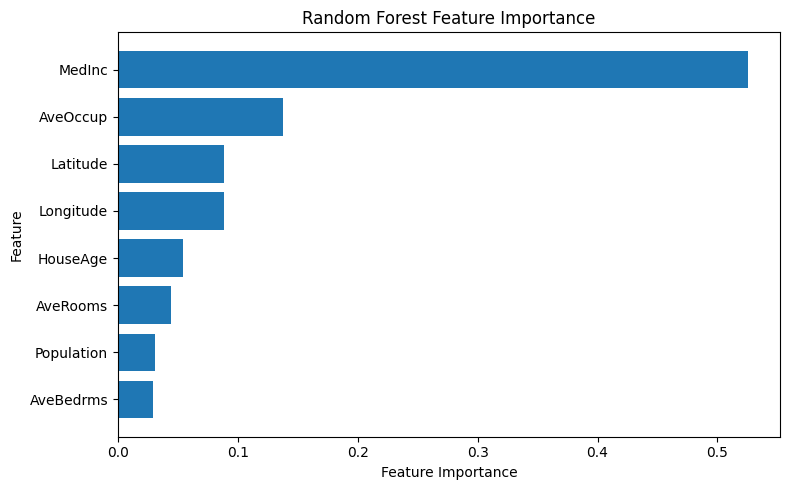

In [30]:
# Random Forest의 feature importance 추출
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance)

# 중요도가 큰 변수부터 위쪽에 보이도록 시각화
plt.figure(figsize=(8, 5))
plt.barh(feature_importance.index, feature_importance.values)
plt.gca().invert_yaxis()
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()


### (BONUS) 1. Boosting 모델 각각의 특징을 정리해보세요.

- **AdaBoost**: 이전 단계에서 잘못 예측한 관측치에 더 큰 가중치를 주면서 다음 약한 학습기를 순차적으로 학습합니다. 비교적 직관적이지만 이상치나 노이즈에 민감할 수 있습니다.
- **Gradient Boosting**: 이전 모델의 오차를 줄이는 방향, 즉 손실함수의 음의 기울기(negative gradient)를 다음 트리가 학습하도록 여러 약한 학습기를 순차적으로 더합니다. `learning_rate`와 `n_estimators`의 조절이 중요합니다.
- **LightGBM**: Gradient Boosting 계열을 빠르고 메모리 효율적으로 구현한 라이브러리입니다. 히스토그램 기반 분할과 leaf-wise 성장을 사용하여 대용량 데이터에서 빠른 편이지만, 데이터가 적을 때 트리가 지나치게 복잡해져 과적합될 수 있습니다.
- **XGBoost**: Gradient Boosting을 고도화한 모델로, 정규화(regularization), 2차 미분 정보를 이용한 최적화, 결측치 처리, 병렬화 등 다양한 기능을 제공합니다. 성능이 강력하지만 조정할 하이퍼파라미터가 많습니다.

공통점은 모두 여러 개의 약한 모델을 결합한다는 점이며, 특히 Boosting 계열은 **앞선 모델의 실수를 다음 모델이 보완하는 방식으로 순차적으로 학습**한다는 특징이 있습니다.


### (BONUS) 2. 모델 성능을 높이기 위하여 어떤 시도를 하면 좋을지 고민해보세요.

1. **하이퍼파라미터 튜닝**: `n_estimators`, `max_depth`, `learning_rate`, `num_leaves`, `min_samples_leaf`, `subsample` 등을 GridSearchCV 또는 RandomizedSearchCV로 탐색합니다.
2. **교차검증(Cross Validation)**: 한 번의 train/test split 결과에만 의존하지 않고 여러 fold에서 성능을 확인하여 더 안정적으로 모델을 선택합니다.
3. **과적합 조절**: 트리 깊이를 줄이거나 최소 leaf 크기를 키우고, Boosting에서는 learning rate를 낮추거나 subsampling/regularization을 사용합니다.
4. **Feature engineering**: 변수 간 관계를 확인해 의미 있는 파생변수를 추가하거나 필요하면 이상치를 점검합니다.
5. **Early stopping**: LightGBM/XGBoost에서는 validation set의 성능이 더 이상 개선되지 않을 때 학습을 중단해 과적합을 줄일 수 있습니다.
6. **여러 평가지표 확인**: MSE뿐 아니라 RMSE, MAE, \(R^2\)도 같이 확인하면 모델의 오차 특성을 더 잘 이해할 수 있습니다.
